# 04 — Diffusion-Innovation VAR

Fit DI-VAR using the same split and forecast protocol as the classical benchmarks. Increase `EPOCHS` only after the full notebook sequence runs successfully.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.experiments import run_financial_experiment

In [2]:
EPOCHS = 25  # smoke run; use a justified larger value for final experiments
returns = pd.read_csv(ROOT / 'data/processed/financial_returns.csv', index_col=0).to_numpy()
result = run_financial_experiment(
    returns, methods=('diffusion',), lags=1, n_paths=250, seed=123,
    diffusion_options={
        'timesteps': 25, 'epochs': EPOCHS, 'hidden_dim': 64,
        'time_embedding_dim': 32, 'batch_size': 64,
        'device': 'cpu', 'verbose': True,
    },
)
result.evaluation

/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


Epoch 0001 | loss = 0.987400
Epoch 0025 | loss = 1.079303


,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,...,width_1,coverage_2,width_2,coverage_3,width_3,coverage_4,width_4,nominal_coverage,coverage_error,abs_coverage_error
0,financial,VAR,diffusion,0.944215,0.044211,0.01449,0.006182,0.048554,0.074518,0.021736,...,0.030279,0.933884,0.040678,0.933884,0.042172,0.991736,0.063714,0.9,0.044215,0.044215


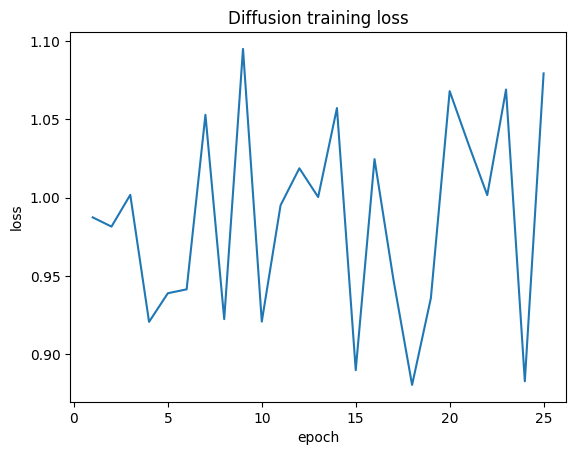

In [3]:
CACHE = ROOT / 'results/notebook_cache'
forecast = result.forecasts['diffusion']
np.savez(CACHE / 'forecast_diffusion.npz', **forecast)
result.evaluation.to_csv(CACHE / 'diffusion_evaluation.csv', index=False)
loss = result.innovation_models['diffusion']['history']['loss']
plt.plot(range(1, len(loss) + 1), loss)
plt.title('Diffusion training loss')
plt.xlabel('epoch')
plt.ylabel('loss');

Training loss is a diagnostic, not evidence of calibrated forecasts. The next notebooks evaluate all models on the same untouched test observations.